# SE-MultiModalTrip

The workflow is:
1. Prepare activity chain data with deterministic activity labels
2. Process the activity chains into the proposed semantic sentence format, i.e. either "{activity_type}:{proportion} separated by +" or the "{time_index}_{activity_type}" format.
3. Either load pre-trained bert-base-uncased, or build a miniature BERT-style model as well as a customised tokeniser, which will be trained from scratch.
4. Feed the tokensied sentences through the model and obtain the embeddings by applying average pooling to the final hidden states.

In [26]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import numpy as np
import math
from transformers import BertTokenizer, BertModel

from pprint import pprint

In [ ]:
city = "london"  # {"london", "singapore"}
str_study_period = "20250210_20250223"
loc_embed_type = "lm_tokenizer"  # language model tokenizer: This is a loose definition.
# In SE-MultiModelTrip, there isn't really a location embedding thing. 
# Because it blurs the notion of location, entirely disregarding the spatial aspects.
# Since the activity chains are converted to sequences of "{activity_type}:{proportion}", which
# are purely semantic.

if city == "london":
    proj_crs = "EPSG:27700"
elif city == "singapore":
    proj_crs = "EPSG:3414"

# Clustering config: almost all are default values suggested by BERTopic -- we do not tune them because it's not the focus of this work.
# These params are kept consistent across all models to ensure a fair comparison of the representation methods.
umap_config = {
    "n_neighbors": 30,  # Controls how UMAP balances local vs global structure (30-50 is good for 100k rows)
    "min_dist": 0.0,  # Set to 0.0 to pack points tightly together for better density clustering
    "n_components": 5,  # The dimensionality of the space to embed into. For visualization, 2 is common. For clustering, the default of 5 is a good starting point, but you can experiment with this.
    "metric": 'cosine',   # Cosine distance should be used for word embeddings-based features
    "random_state": 101  # For reproducibility
}

## Data

In [44]:
# Just a helper function to find the data directory by searching the current and parent directories.

def get_data_dir_path(target_dir_str="mobility_data"):
    """
    Get data dir by seearching the current directory for the folder named 
    If there is no folder named {target_dir_str}, then search the parrent directory for it.
    Do this until a folder named {target_dir_str} is found or the root directory is reached
    """
    current_dir = os.getcwd()
    target_data_dir = None
    while True:
        if target_dir_str in os.listdir(current_dir):
            target_data_dir = os.path.join(current_dir, target_dir_str)
            break
        else:
            parent_dir = os.path.dirname(current_dir)
            if parent_dir == current_dir:  # Reached the root directory
                print(f"Error: Could not find a folder named '{target_dir_str}' in the current directory or any of its parent directories.")
                break
            current_dir = parent_dir
    return target_data_dir

In [48]:
mobility_data_dir = get_data_dir_path("mobility_data")
mobility_data_file = f"{city}_{str_study_period}_stays_bbox_min2staysperday_with_sigplaces.csv.gz"
mobility_data_path = os.path.join(mobility_data_dir, mobility_data_file)
print(f"Loading mobility data from {mobility_data_path}...\n")

df_stays = pd.read_csv(mobility_data_path)
df_stays.head()

Loading mobility data from /home/xlwang/code/2026/ace_dev/mobility_data/london_20250210_20250223_stays_bbox_min2staysperday_with_sigplaces.csv.gz...



,user_id,start_time,end_time,longitude,latitude,significant_place
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 13:52:23,2025-02-18 14:45:13,-0.166586,51.481968,1
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 19:43:05,2025-02-18 22:53:39,-0.133383,51.323275,0
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19 01:43:03,2025-02-19 10:49:59,-0.133407,51.323269,0
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19 17:46:28,2025-02-19 22:43:03,-0.133356,51.323277,0


Get the deterministic semantic type for each sig place

Each significant place is associated with an activity type

These have been pre-computed (in se_act_chian.ipynb) and saved, so we just need to load them directly from disk.

In [46]:
# Load from local
df_sigplaces_with_det_sem = pd.read_csv(f'../se_act_chain/{city}_sigplaces_with_inferred_activity.csv.gz', compression='gzip')
if "list_groupname" in df_sigplaces_with_det_sem.columns:
    df_sigplaces_with_det_sem.drop(columns=['list_groupname'], inplace=True)
if "is_home" in df_sigplaces_with_det_sem.columns:
    df_sigplaces_with_det_sem.drop(columns=['is_home'], inplace=True)

df_sigplaces_with_det_sem

,user_id,significant_place,cluster_x,cluster_y,inferred_activity
0,000088cc-b646-409b-a026-69cd9d47b838,0,530161.650419,159894.898575,Home
1,000088cc-b646-409b-a026-69cd9d47b838,1,527406.321829,177483.676174,Attractions
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,553352.580561,182964.732347,Home
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,553875.110693,182649.901302,Transport
4,000135bd-bf0b-4880-af99-1791ce98dddf,0,521030.394811,168403.307828,Home
...,...,...,...,...,...
937808,ffff8ebb-33d5-4851-a36d-12de4548ea2e,7,535298.958350,191977.129395,Retail
937809,ffff8ebb-33d5-4851-a36d-12de4548ea2e,8,534199.999362,191917.508375,Commercial Services
937810,ffff8ebb-33d5-4851-a36d-12de4548ea2e,9,532805.730369,196302.510275,Retail
937811,ffff8ebb-33d5-4851-a36d-12de4548ea2e,10,536249.589648,185336.063915,Attractions


In [6]:
df_sigplaces_with_det_sem['inferred_activity'].value_counts()

inferred_activity
Accommodation, Eating and Drinking    190094
Retail                                184128
Home                                  112138
Commercial Services                   103536
Transport                              85447
Education and Health                   83487
Attractions                            56737
Manufacturing and Production           48358
Sport and Entertainment                35607
Public Infrastructure                  27563
Other                                  10718
Name: count, dtype: int64

In [49]:
# Merge with df_stays
df_stays = pd.merge(df_stays, df_sigplaces_with_det_sem[['user_id', 'significant_place', 'inferred_activity']], 
                    on=['user_id', 'significant_place'], how='left')

# Get the time indices for each stay with 30 minutes as the interval, e.g., 00:00-00:29 -> 0, 00:30-00:59 -> 1, ..., 23:30-23:59 -> 47
df_stays['start_time'] = pd.to_datetime(df_stays['start_time'])
df_stays['start_time_index'] = df_stays['start_time'].dt.hour * 2 + df_stays['start_time'].dt.minute // 30
df_stays['end_time'] = pd.to_datetime(df_stays['end_time'])
df_stays['end_time_index'] = df_stays['end_time'].dt.hour * 2 + df_stays['end_time'].dt.minute // 30

df_stays['date'] = df_stays['start_time'].dt.date

df_stays['active_time_indices'] = df_stays.apply(lambda row: list(range(row['start_time_index'], row['end_time_index'] + 1)), axis=1)
# Explode the active_time_indices into multiple rows
df_stays = df_stays.explode('active_time_indices').reset_index(drop=True).rename(columns={'active_time_indices': 'time_index'})

df_stays

,user_id,start_time,end_time,longitude,latitude,significant_place,inferred_activity,start_time_index,end_time_index,date,time_index
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,3
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,4
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,5
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,6
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,7
...,...,...,...,...,...,...,...,...,...,...,...
29513499,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,43
29513500,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,44
29513501,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,45
29513502,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,46


## Modelling

In [8]:
def construct_daily_activity_corpus(
    df_stays,
    user_col='user_id',
    date_col='date',
    time_col='time_index',
    activity_col='inferred_activity',
):
    """
    Constructs one 48-word daily activity chain for each user-day.

    Returns a daily_chain_index DataFrame with one row per (user_id, date):
    - user_id
    - date
    - daily_activity_chain
    - day_type: weekday or weekend

    The row order of daily_chain_index is the alignment key for daily embeddings.
    """
    df = df_stays.copy()
    df = df.drop_duplicates(subset=[user_col, date_col, time_col], keep='last')
    df[activity_col] = df[activity_col].fillna('Unknown').astype(str)

    df_pivot = df.pivot(index=[user_col, date_col], columns=time_col, values=activity_col)
    df_pivot = df_pivot.reindex(columns=range(48)).fillna('Unknown')

    daily_chain_index = df_pivot.reset_index()
    chain_cols = list(range(48))
    daily_chain_index['daily_activity_chain'] = daily_chain_index[chain_cols].apply(
        lambda row: [f"{time_index}_{activity}" for time_index, activity in row.items()],
        axis=1,
    )
    daily_chain_index = daily_chain_index[[user_col, date_col, 'daily_activity_chain']]

    date_values = pd.to_datetime(daily_chain_index[date_col])
    daily_chain_index['day_type'] = np.where(date_values.dt.dayofweek < 5, 'weekday', 'weekend')

    return daily_chain_index

In [9]:
class CustomTokenizer:
    """A lightweight tokeniser that builds a vocabulary from the training corpus."""
    def __init__(self):
        self.word2idx = {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3}
        self.idx2word = {0: '[PAD]', 1: '[UNK]', 2: '[CLS]', 3: '[SEP]'}

    def fit(self, corpus_strings):
        for text in corpus_strings:
            # Pad the '+' operator so it becomes its own distinct token
            tokens = text.replace('+', ' + ').split()
            for token in tokens:
                if token not in self.word2idx:
                    idx = len(self.word2idx)
                    self.word2idx[token] = idx
                    self.idx2word[idx] = token

    def encode(self, text, max_len=60):
        tokens = text.replace('+', ' + ').split()
        encoded = [self.word2idx['[CLS]']]
        encoded += [self.word2idx.get(t, self.word2idx['[UNK]']) for t in tokens]
        encoded += [self.word2idx['[SEP]']]
        
        # Create attention mask (1 for real tokens, 0 for padding)
        mask = [1] * len(encoded)
        
        # Pad to max_len
        if len(encoded) < max_len:
            pad_len = max_len - len(encoded)
            encoded += [self.word2idx['[PAD]']] * pad_len
            mask += [0] * pad_len
            
        return encoded[:max_len], mask[:max_len]

class PositionalEncoding(nn.Module):
    """Injects sequence order information into the embedding."""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

class MiniBERT(nn.Module):
    """A highly compressed Transformer Encoder for bespoke vocabularies."""
    def __init__(self, vocab_size, embed_dim=64, num_heads=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x = self.pos_encoder(x)
        
        # PyTorch TransformerEncoder expects a boolean padding mask (True for padded positions)
        key_padding_mask = (attention_mask == 0)
        hidden_states = self.transformer(x, src_key_padding_mask=key_padding_mask)
        
        return hidden_states

In [10]:
class SEMultiModalTripEmbedder:
    """
    Implementation of the MultiModalTrip embedding model (with added flexibility), adapted for semantic embedding of activity chains.
    If you run format_type="proportional" alongside model_type="custom", the custom tokeniser will encounter decimals (e.g. 0.33, 0.42) and map them as entirely unique words. 
    This is structurally sound and will not crash, but it means the model views Home:0.33 and Home:0.34 as completely unrelated tokens. 
    The pretrained model bypasses this issue because its WordPiece tokeniser splits the decimal into its constituent numbers. 
    Therefore, "proportional" is generally best paired with "pretrained", and "absolute" pairs flawlessly with either.
    """
    def __init__(self, format_type="proportional", model_type="pretrained"):
        assert format_type in ["proportional", "absolute"], "format_type must be 'proportional' or 'absolute'"
        assert model_type in ["pretrained", "custom"], "model_type must be 'pretrained' or 'custom'"
        
        self.format_type = format_type
        self.model_type = model_type
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        self.tokenizer = None
        self.model = None

    def _format_sequence(self, chain):
        """Converts the 48-slot array into the desired text string format."""
        if self.format_type == "absolute":
            return " ".join(chain)
            
        elif self.format_type == "proportional":
            # Strip only the leading time index (e.g., '16_Work' -> 'Work')
            activities = [c.split('_', 1)[1] if '_' in c else c for c in chain]
            
            blocks = []
            current_act = activities[0]
            count = 1
            
            # Compress consecutive identical activities into blocks
            for act in activities[1:]:
                if act == current_act:
                    count += 1
                else:
                    blocks.append((current_act, count))
                    current_act = act
                    count = 1
            blocks.append((current_act, count))
            
            total_len = len(activities)
            # Format: Activity:Proportion separated by + (e.g., Home:0.33+Work:0.67)
            string_blocks = [f"{act}:{count/total_len:.2f}" for act, count in blocks]
            return "+".join(string_blocks)

    def _initialise_model(self, corpus_strings):
        """Loads the appropriate tokeniser and model."""
        if self.model_type == "pretrained":
            print("Loading pre-trained bert-base-uncased...")
            self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
            self.model = BertModel.from_pretrained('bert-base-uncased').to(self.device)
            
        elif self.model_type == "custom":
            print("Compiling custom Mini-BERT and building vocabulary...")
            self.tokenizer = CustomTokenizer()
            self.tokenizer.fit(corpus_strings)
            vocab_size = len(self.tokenizer.word2idx)
            
            # Using an embedding dimension of 64 for speed (can be tuned)
            self.model = MiniBERT(vocab_size=vocab_size, embed_dim=64).to(self.device)
            
        self.model.eval()

    def fit_transform(self, activity_chains, batch_size=32):
        """Orchestrates the entire semantic embedding pipeline."""
        # 1. Format the inputs
        corpus_strings = [self._format_sequence(chain) for chain in activity_chains]
        
        # 2. Initialise architecture
        self._initialise_model(corpus_strings)
        
        all_embeddings = []
        
        # 3. Process in batches to manage memory
        with torch.no_grad():
            for i in range(0, len(corpus_strings), batch_size):
                batch_texts = corpus_strings[i : i + batch_size]
                
                if self.model_type == "pretrained":
                    inputs = self.tokenizer(batch_texts, padding=True, truncation=True, 
                                            max_length=128, return_tensors="pt").to(self.device)
                    outputs = self.model(**inputs)
                    hidden_states = outputs.last_hidden_state
                    attention_mask = inputs['attention_mask']
                    
                elif self.model_type == "custom":
                    batch_ids, batch_masks = [], []
                    for text in batch_texts:
                        ids, mask = self.tokenizer.encode(text, max_len=60)
                        batch_ids.append(ids)
                        batch_masks.append(mask)
                        
                    input_ids = torch.tensor(batch_ids, dtype=torch.long).to(self.device)
                    attention_mask = torch.tensor(batch_masks, dtype=torch.long).to(self.device)
                    
                    hidden_states = self.model(input_ids, attention_mask)

                # 4. Average Pooling (masking out padded tokens)
                mask_expanded = attention_mask.unsqueeze(-1).float()
                sum_embeddings = torch.sum(hidden_states * mask_expanded, dim=1)
                sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
                pooled_embeddings = sum_embeddings / sum_mask
                
                all_embeddings.append(pooled_embeddings.cpu().numpy())

        return np.vstack(all_embeddings)

In [11]:
# Construct one shared user-day index; derive weekday/weekend corpora from it later.
daily_chain_index = construct_daily_activity_corpus(df_stays)

print(f"Total daily activity chains: {len(daily_chain_index)}")
print(f"Total users with daily activity chains: {daily_chain_index['user_id'].nunique()}")

for day_type, day_index in daily_chain_index.groupby('day_type', sort=False):
    print(f"{day_type}: {len(day_index)} daily activity chains")
    print(f"{day_type}: {day_index['user_id'].nunique()} users")
    if not day_index.empty:
        print(f"{day_type}: {len(day_index.iloc[0]['daily_activity_chain'])} slots per daily chain")  # Should be 48

daily_chain_index.head()


Total daily activity chains: 785835
Total users with daily activity chains: 112138
weekday: 579488 daily activity chains
weekday: 104741 users
weekday: 48 slots per daily chain
weekend: 206347 daily activity chains
weekend: 83125 users
weekend: 48 slots per daily chain


time_index,user_id,date,daily_activity_chain,day_type
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,"[0_Unknown, 1_Unknown, 2_Unknown, 3_Home, 4_Ho...",weekday
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19,"[0_Unknown, 1_Unknown, 2_Unknown, 3_Home, 4_Ho...",weekday
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,2025-02-15,"[0_Unknown, 1_Unknown, 2_Unknown, 3_Unknown, 4...",weekend
3,000135bd-bf0b-4880-af99-1791ce98dddf,2025-02-10,"[0_Home, 1_Home, 2_Home, 3_Home, 4_Home, 5_Hom...",weekday
4,000135bd-bf0b-4880-af99-1791ce98dddf,2025-02-11,"[0_Home, 1_Home, 2_Home, 3_Home, 4_Home, 5_Hom...",weekday


In [25]:
# Synthesising dummy data for testing
# Chain 1: Night shift worker (Home -> Work -> Home)
chain_1 = [f"{i}_Home" for i in range(0, 16)] + \
          [f"{i}_Work" for i in range(16, 36)] + \
          [f"{i}_Home" for i in range(36, 48)]

# Chain 2: Commuter with shopping block
chain_2 = [f"{i}_Home" for i in range(0, 16)] + \
          [f"{i}_Work" for i in range(16, 30)] + \
          [f"{i}_Retail" for i in range(30, 36)] + \
          [f"{i}_Home" for i in range(36, 48)]

corpus = [chain_1, chain_2]

print("--- TESTING PROPORTIONAL + PRETRAINED ---")
embedder_a = SEMultiModalTripEmbedder(format_type="proportional", model_type="pretrained")
embeddings_a = embedder_a.fit_transform(corpus)
print(f"Format example: {embedder_a._format_sequence(corpus[1])}")
print(f"Embedding shape: {embeddings_a.shape}")

--- TESTING PROPORTIONAL + PRETRAINED ---
Loading pre-trained bert-base-uncased...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Format example: Home:0.33+Work:0.29+Retail:0.12+Home:0.25
Embedding shape: (2, 768)


In [26]:
print(len(chain_1))

48


In [12]:
def aggregate_embeddings_by_user(user_ids, embeddings):
    """Mean-pool row embeddings by user without building a huge daily embedding DataFrame."""
    user_index = pd.Index(pd.Series(user_ids).astype(str), name='user_id')
    unique_users, inverse = np.unique(user_index.to_numpy(), return_inverse=True)

    sums = np.zeros((len(unique_users), embeddings.shape[1]), dtype=np.float64)
    counts = np.zeros(len(unique_users), dtype=np.int64)
    np.add.at(sums, inverse, embeddings)
    np.add.at(counts, inverse, 1)

    user_embeddings = (sums / counts[:, None]).astype(np.float32)
    return unique_users, user_embeddings


def make_embedding_df(index_df, embeddings, embedding_prefix):
    """
    Reconstruct an embedding DataFrame on demand for inspection or small exports.
    Avoid calling this for the full daily corpus unless you really need a wide table.
    """
    embedding_cols = [f"{embedding_prefix}_{i}" for i in range(embeddings.shape[1])]
    return pd.concat(
        [
            index_df.reset_index(drop=True),
            pd.DataFrame(embeddings, columns=embedding_cols),
        ],
        axis=1,
    )


def fit_save_and_aggregate_user_activity_embeddings(
    day_type,
    daily_chain_index,
    model_output_dir,
    user_col='user_id',
    date_col='date',
    chain_col='daily_activity_chain',
    format_type='proportional',
    model_type='pretrained',
    batch_size=512,
):
    """
    Embeds one day type with SE-MultiModalTrip and aggregates daily chain
    embeddings into user-level activity-pattern embeddings.

    Dense embedding matrices are saved as compressed .npz files. Lightweight
    CSV files store only row metadata, avoiding huge and slow 768-column CSVs.
    """
    day_chain_index = (
        daily_chain_index[daily_chain_index['day_type'] == day_type]
        .reset_index(drop=True)
        .copy()
    )
    if day_chain_index.empty:
        raise ValueError(f"No daily activity chains available for {day_type}.")

    corpus = day_chain_index[chain_col].tolist()
    if not all(len(chain) == 48 for chain in corpus):
        raise ValueError(f"Expected all {day_type} daily activity chains to have 48 time slots.")

    embedder = SEMultiModalTripEmbedder(
        format_type=format_type,
        model_type=model_type,
    )
    formatted_activity_sentences = [embedder._format_sequence(chain) for chain in corpus]
    daily_chain_embeddings = embedder.fit_transform(corpus, batch_size=batch_size).astype(np.float32)

    os.makedirs(model_output_dir, exist_ok=True)
    output_prefix = f"se_multimodaltrip_{day_type}_{format_type}_{model_type}"

    daily_metadata_df = day_chain_index[[user_col, date_col, 'day_type']].reset_index(drop=True).copy()
    daily_metadata_df['formatted_activity_sentence'] = formatted_activity_sentences
    daily_metadata_path = os.path.join(model_output_dir, f"{output_prefix}_daily_metadata.csv.gz")
    daily_metadata_df.to_csv(daily_metadata_path, index=False, compression='gzip')

    daily_embedding_npz_path = os.path.join(model_output_dir, f"{output_prefix}_daily_embeddings.npz")
    np.savez_compressed(
        daily_embedding_npz_path,
        embedding=daily_chain_embeddings,
        user_id=daily_metadata_df[user_col].to_numpy(),
        date=daily_metadata_df[date_col].astype(str).to_numpy(),
        day_type=daily_metadata_df['day_type'].to_numpy(),
        format_type=format_type,
        model_type=model_type,
    )

    user_ids, user_activity_embeddings_array = aggregate_embeddings_by_user(
        daily_metadata_df[user_col].to_numpy(),
        daily_chain_embeddings,
    )
    user_metadata_df = pd.DataFrame({'user_id': user_ids})
    user_metadata_path = os.path.join(model_output_dir, f"{output_prefix}_user_metadata.csv.gz")
    user_metadata_df.to_csv(user_metadata_path, index=False, compression='gzip')

    user_embedding_npz_path = os.path.join(model_output_dir, f"{output_prefix}_user_embeddings.npz")
    np.savez_compressed(
        user_embedding_npz_path,
        embedding=user_activity_embeddings_array,
        user_id=user_ids,
        format_type=format_type,
        model_type=model_type,
    )

    embedding_prefix = f"se_multimodaltrip_{day_type}"
    user_activity_embedding_df = make_embedding_df(
        user_metadata_df,
        user_activity_embeddings_array,
        embedding_prefix,
    ).set_index('user_id')
    user_activity_embeddings = {
        user_id: row
        for user_id, row in zip(user_ids, user_activity_embeddings_array)
    }

    return {
        'day_type': day_type,
        'corpus': corpus,
        'embedder': embedder,
        'daily_metadata_df': daily_metadata_df,
        'daily_metadata_path': daily_metadata_path,
        'daily_chain_embeddings': daily_chain_embeddings,
        'daily_embedding_npz_path': daily_embedding_npz_path,
        'user_metadata_df': user_metadata_df,
        'user_metadata_path': user_metadata_path,
        'user_activity_embeddings_array': user_activity_embeddings_array,
        'user_activity_embeddings': user_activity_embeddings,
        'user_activity_embedding_df': user_activity_embedding_df,
        'user_embedding_npz_path': user_embedding_npz_path,
    }


In [13]:
se_multimodaltrip_format_type = 'proportional'
se_multimodaltrip_model_type = 'pretrained'
se_multimodaltrip_batch_size = 512

model_output_dir = os.path.join(
    'pretrained_se_multimodaltrip',
    f'{city}_{str_study_period}',
    f'{se_multimodaltrip_format_type}_{se_multimodaltrip_model_type}',
)

day_types = ['weekday', 'weekend']
se_multimodaltrip_results = {
    day_type: fit_save_and_aggregate_user_activity_embeddings(
        day_type,
        daily_chain_index,
        model_output_dir,
        format_type=se_multimodaltrip_format_type,
        model_type=se_multimodaltrip_model_type,
        batch_size=se_multimodaltrip_batch_size,
    )
    for day_type in day_types
}

weekday_results = se_multimodaltrip_results['weekday']
weekend_results = se_multimodaltrip_results['weekend']

weekday_training_corpus = weekday_results['corpus']
weekend_training_corpus = weekend_results['corpus']
weekday_embedder = weekday_results['embedder']
weekend_embedder = weekend_results['embedder']
weekday_daily_metadata_df = weekday_results['daily_metadata_df']
weekend_daily_metadata_df = weekend_results['daily_metadata_df']
weekday_daily_chain_embeddings = weekday_results['daily_chain_embeddings']
weekend_daily_chain_embeddings = weekend_results['daily_chain_embeddings']
weekday_user_activity_embeddings = weekday_results['user_activity_embeddings']
weekend_user_activity_embeddings = weekend_results['user_activity_embeddings']
weekday_user_activity_embeddings_array = weekday_results['user_activity_embeddings_array']
weekend_user_activity_embeddings_array = weekend_results['user_activity_embeddings_array']
weekday_user_activity_embedding_df = weekday_results['user_activity_embedding_df']
weekend_user_activity_embedding_df = weekend_results['user_activity_embedding_df']

for day_type, results in se_multimodaltrip_results.items():
    print(f"{day_type.capitalize()} training corpus: {len(results['corpus'])} daily chains")
    print(f"{day_type.capitalize()} daily chain embeddings: {results['daily_chain_embeddings'].shape}")
    print(f"{day_type.capitalize()} user activity embeddings: {results['user_activity_embeddings_array'].shape}")
    print(f"Saved daily metadata to: {results['daily_metadata_path']}")
    print(f"Saved daily embedding matrix to: {results['daily_embedding_npz_path']}")
    print(f"Saved user metadata to: {results['user_metadata_path']}")
    print(f"Saved user embedding matrix to: {results['user_embedding_npz_path']}")


Loading pre-trained bert-base-uncased...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading pre-trained bert-base-uncased...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Weekday training corpus: 579488 daily chains
Weekday daily chain embeddings: (579488, 768)
Weekday user activity embeddings: (104741, 768)
Saved daily metadata to: pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/se_multimodaltrip_weekday_proportional_pretrained_daily_metadata.csv.gz
Saved daily embedding matrix to: pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/se_multimodaltrip_weekday_proportional_pretrained_daily_embeddings.npz
Saved user metadata to: pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/se_multimodaltrip_weekday_proportional_pretrained_user_metadata.csv.gz
Saved user embedding matrix to: pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/se_multimodaltrip_weekday_proportional_pretrained_user_embeddings.npz
Weekend training corpus: 206347 daily chains
Weekend daily chain embeddings: (206347, 768)
Weekend user activity embeddings: (83125, 768)
Saved daily m

# Clustering

In [11]:
import os
import gc
import pickle

import numpy as np
import pandas as pd
import umap
from sklearn.cluster import HDBSCAN
from hdbscan.validity import validity_index


In [12]:
city = "london"  # {"london", "singapore"}
str_study_period = "20250210_20250223"
se_multimodaltrip_format_type = 'proportional'
se_multimodaltrip_model_type = 'pretrained'

model_output_dir = os.path.join(
    'pretrained_se_multimodaltrip',
    f'{city}_{str_study_period}',
    f'{se_multimodaltrip_format_type}_{se_multimodaltrip_model_type}',
)
clustering_output_dir = os.path.join(model_output_dir, 'clustering')
os.makedirs(clustering_output_dir, exist_ok=True)

# UMAP reduces each user activity-pattern embedding from 768D to 5D for clustering.
umap_clustering_config = {
    'n_neighbors': 30,
    'min_dist': 0.0,
    'n_components': 5,
    'metric': 'cosine',
    'random_state': 101,
}

hdbscan_params_combinations = [
    {'min_cluster_size': 1000, 'min_samples': 30},
    {'min_cluster_size': 1000, 'min_samples': 50},
    {'min_cluster_size': 1000, 'min_samples': 100},
    {'min_cluster_size': 1000, 'min_samples': 200},
    {'min_cluster_size': 1000, 'min_samples': 300},
    {'min_cluster_size': 1000, 'min_samples': 500},
    {'min_cluster_size': 1000, 'min_samples': 1000},
    {'min_cluster_size': 2000, 'min_samples': 30},
    {'min_cluster_size': 2000, 'min_samples': 50},
    {'min_cluster_size': 2000, 'min_samples': 100},
    {'min_cluster_size': 2000, 'min_samples': 200},
    {'min_cluster_size': 2000, 'min_samples': 500},
    {'min_cluster_size': 2000, 'min_samples': 1000},
    {'min_cluster_size': 2000, 'min_samples': 2000},
]

# DBCV is higher when clusters are denser and better separated.
dbcv_metric = 'euclidean'
# Exact full-data DBCV can be slow. Use None for exact, or e.g. 30000 for a sampled score.
dbcv_sample_size = 30000
dbcv_random_state = umap_clustering_config['random_state']


def load_saved_user_embeddings(day_type, model_output_dir):
    output_prefix = (
        f'se_multimodaltrip_{day_type}_'
        f'{se_multimodaltrip_format_type}_{se_multimodaltrip_model_type}'
    )
    user_metadata_path = os.path.join(model_output_dir, f'{output_prefix}_user_metadata.csv.gz')
    user_embedding_npz_path = os.path.join(model_output_dir, f'{output_prefix}_user_embeddings.npz')

    if not os.path.exists(user_metadata_path):
        raise FileNotFoundError(f'Missing user metadata file: {user_metadata_path}')
    if not os.path.exists(user_embedding_npz_path):
        raise FileNotFoundError(f'Missing user embedding file: {user_embedding_npz_path}')

    user_metadata_df = pd.read_csv(user_metadata_path)
    embedding_npz = np.load(user_embedding_npz_path, allow_pickle=True)
    user_activity_embeddings_array = embedding_npz['embedding'].astype(np.float32)
    npz_user_ids = embedding_npz['user_id'].astype(str)
    metadata_user_ids = user_metadata_df['user_id'].astype(str).to_numpy()

    if not np.array_equal(npz_user_ids, metadata_user_ids):
        raise ValueError(f'{day_type}: user_id order mismatch between metadata CSV and embedding NPZ.')

    return {
        'day_type': day_type,
        'user_metadata_df': user_metadata_df,
        'user_activity_embeddings_array': user_activity_embeddings_array,
        'user_embedding_npz_path': user_embedding_npz_path,
        'user_metadata_path': user_metadata_path,
    }


weekday_results = load_saved_user_embeddings('weekday', model_output_dir)
weekend_results = load_saved_user_embeddings('weekend', model_output_dir)
weekday_user_activity_embeddings_array = weekday_results['user_activity_embeddings_array']
weekend_user_activity_embeddings_array = weekend_results['user_activity_embeddings_array']

print(f"Loaded weekday user embeddings: {weekday_user_activity_embeddings_array.shape}")
print(f"Loaded weekend user embeddings: {weekend_user_activity_embeddings_array.shape}")


Loaded weekday user embeddings: (104741, 768)
Loaded weekend user embeddings: (83125, 768)


In [15]:
def _make_dbcv_score_subset(labels, sample_size=dbcv_sample_size, random_state=dbcv_random_state):
    if sample_size is None or sample_size >= len(labels):
        return np.arange(len(labels))
    rng = np.random.default_rng(random_state)
    return np.sort(rng.choice(len(labels), size=sample_size, replace=False))


def reduce_user_embeddings_with_umap(day_type, user_ids, user_embeddings, output_dir):
    input_embedding = np.asarray(user_embeddings, dtype=np.float32)
    input_dim = input_embedding.shape[1]
    n_components = umap_clustering_config['n_components']

    umap_embedding_path = os.path.join(
        output_dir,
        f'se_multimodaltrip_{day_type}_umap{n_components}d.npz',
    )
    if os.path.exists(umap_embedding_path):
        cached = np.load(umap_embedding_path, allow_pickle=True)
        umap_embedding = cached['embedding']
        cached_user_ids = cached['user_id'].astype(str)
        if not np.array_equal(cached_user_ids, np.asarray(user_ids).astype(str)):
            raise ValueError(
                f'{day_type}: cached UMAP embedding user_id order does not match current embeddings: '
                f'{umap_embedding_path}'
            )
        print(f'{day_type}: loaded {n_components}D UMAP embedding from {umap_embedding_path}')
    else:
        reducer = umap.UMAP(**umap_clustering_config)
        umap_embedding = reducer.fit_transform(input_embedding)
        np.savez_compressed(
            umap_embedding_path,
            embedding=umap_embedding.astype(np.float32),
            user_id=np.asarray(user_ids).astype(str),
            source_embedding_dim=input_dim,
        )
        print(f'{day_type}: saved {input_dim}D -> {n_components}D UMAP embedding to {umap_embedding_path}')

    umap_cols = [f'umap_{i}' for i in range(n_components)]
    umap_embedding_df = pd.DataFrame(
        umap_embedding,
        index=pd.Index(np.asarray(user_ids).astype(str), name='user_id'),
        columns=umap_cols,
    )
    return umap_embedding_df, umap_embedding_path


def evaluate_hdbscan_dbcv(embedding, params):
    min_cluster_size = params['min_cluster_size']
    min_samples = params['min_samples']
    print(f'Evaluating min_cluster_size={min_cluster_size}, min_samples={min_samples}...')

    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=dbcv_metric,
        copy=True,
    ).fit(embedding)

    labels = clusterer.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = np.count_nonzero(labels == -1)
    proportion_outliers = n_outliers / len(labels)

    if n_clusters < 2:
        dbcv_score = np.nan
        dbcv_error = 'DBCV requires at least two non-noise clusters'
        score_n_users = 0
    else:
        score_idx = _make_dbcv_score_subset(labels)
        score_embedding = np.asarray(embedding[score_idx], dtype=np.float64)
        score_labels = labels[score_idx]
        score_n_clusters = len(set(score_labels)) - (1 if -1 in score_labels else 0)
        score_n_users = len(score_idx)
        if score_n_clusters < 2:
            dbcv_score = np.nan
            dbcv_error = 'DBCV sample has fewer than two non-noise clusters'
        else:
            try:
                dbcv_score = validity_index(score_embedding, score_labels, metric=dbcv_metric)
                dbcv_error = None
            except Exception as exc:
                dbcv_score = np.nan
                dbcv_error = repr(exc)

    # scikit-learn's HDBSCAN does not expose cluster_persistence_.
    mean_cluster_persistence = np.nan

    result = {
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'num_clusters': n_clusters,
        'num_outliers': n_outliers,
        'proportion_outliers': proportion_outliers,
        'dbcv_score': dbcv_score,
        'dbcv_sample_size': dbcv_sample_size,
        'dbcv_scored_users': score_n_users,
        'mean_cluster_persistence': mean_cluster_persistence,
        'dbcv_error': dbcv_error,
    }
    print(
        f'DBCV={dbcv_score:.4f} | clusters={n_clusters} | outliers={n_outliers} ({proportion_outliers:.2%})'
        if np.isfinite(dbcv_score)
        else f'DBCV=nan | clusters={n_clusters} | error={dbcv_error}'
    )
    return result


In [16]:
def cluster_user_activity_embeddings(day_type, user_ids, user_embeddings, output_dir):
    umap_embedding_df, umap_embedding_path = reduce_user_embeddings_with_umap(
        day_type,
        user_ids,
        user_embeddings,
        output_dir,
    )
    embedding = umap_embedding_df.to_numpy(dtype=np.float64)

    dbcv_rows = []
    for params in hdbscan_params_combinations:
        dbcv_rows.append(evaluate_hdbscan_dbcv(embedding, params))
        gc.collect()

    df_hdbscan_dbcv = pd.DataFrame(dbcv_rows).sort_values(
        by=['dbcv_score', 'proportion_outliers'],
        ascending=[False, True],
        na_position='last',
    )
    dbcv_summary_path = os.path.join(
        output_dir,
        f'hdbscan_dbcv_summary_se_multimodaltrip_{day_type}_umap{umap_clustering_config["n_components"]}d.csv',
    )
    df_hdbscan_dbcv.to_csv(dbcv_summary_path, index=False)

    valid_dbcv = df_hdbscan_dbcv.dropna(subset=['dbcv_score'])
    if valid_dbcv.empty:
        raise ValueError(f'No valid DBCV score found for {day_type}. Check the parameter grid or embeddings.')

    best_params = valid_dbcv.iloc[0][['min_cluster_size', 'min_samples']].astype(int).to_dict()
    best_clusterer = HDBSCAN(
        min_cluster_size=best_params['min_cluster_size'],
        min_samples=best_params['min_samples'],
        metric=dbcv_metric,
        copy=True,
    ).fit(embedding)

    cluster_col = (
        f'clst_se_multimodaltrip_{day_type}_umap{umap_clustering_config["n_components"]}d_'
        f'size{best_params["min_cluster_size"]}_sample{best_params["min_samples"]}'
    )
    clustering_result_df = umap_embedding_df.reset_index()
    clustering_result_df[cluster_col] = best_clusterer.labels_

    clustering_result_path = os.path.join(
        output_dir,
        f'user_clustering_results_se_multimodaltrip_{day_type}.csv',
    )
    clustering_result_df.to_csv(clustering_result_path, index=False)

    clusterer_path = os.path.join(
        output_dir,
        f'hdbscan_se_multimodaltrip_{day_type}_umap{umap_clustering_config["n_components"]}d_'
        f'size{best_params["min_cluster_size"]}_sample{best_params["min_samples"]}.pkl',
    )
    with open(clusterer_path, 'wb') as f:
        pickle.dump(best_clusterer, f)

    n_clusters = len(set(best_clusterer.labels_)) - (1 if -1 in best_clusterer.labels_ else 0)
    n_outliers = np.count_nonzero(best_clusterer.labels_ == -1)
    print(f'{day_type}: DBCV summary saved to {dbcv_summary_path}')
    print(f'{day_type}: best params = {best_params}')
    print(f'{day_type}: {n_clusters} clusters, {n_outliers} outliers ({n_outliers / len(best_clusterer.labels_):.2%})')
    print(f'{day_type}: clustering results saved to {clustering_result_path}')
    print(f'{day_type}: HDBSCAN model saved to {clusterer_path}')

    return {
        'day_type': day_type,
        'umap_embedding_df': umap_embedding_df,
        'umap_embedding_path': umap_embedding_path,
        'dbcv_summary_df': df_hdbscan_dbcv,
        'dbcv_summary_path': dbcv_summary_path,
        'best_params': best_params,
        'clusterer': best_clusterer,
        'clusterer_path': clusterer_path,
        'cluster_col': cluster_col,
        'clustering_result_df': clustering_result_df,
        'clustering_result_path': clustering_result_path,
    }


In [5]:
se_multimodaltrip_clustering_results = {
    'weekday': cluster_user_activity_embeddings(
        'weekday',
        weekday_results['user_metadata_df']['user_id'].to_numpy(),
        weekday_user_activity_embeddings_array,
        clustering_output_dir,
    ),
    'weekend': cluster_user_activity_embeddings(
        'weekend',
        weekend_results['user_metadata_df']['user_id'].to_numpy(),
        weekend_user_activity_embeddings_array,
        clustering_output_dir,
    ),
}

weekday_clustering_results = se_multimodaltrip_clustering_results['weekday']
weekend_clustering_results = se_multimodaltrip_clustering_results['weekend']
weekday_user_clustering_df = weekday_clustering_results['clustering_result_df']
weekend_user_clustering_df = weekend_clustering_results['clustering_result_df']
weekday_hdbscan_dbcv_df = weekday_clustering_results['dbcv_summary_df']
weekend_hdbscan_dbcv_df = weekend_clustering_results['dbcv_summary_df']

for day_type, results in se_multimodaltrip_clustering_results.items():
    print(f"{day_type}: retained column {results['cluster_col']}")
    print(results['dbcv_summary_df'].head())


weekday: loaded 5D UMAP embedding from pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/clustering/se_multimodaltrip_weekday_umap5d.npz
Evaluating min_cluster_size=1000, min_samples=30...
DBCV=0.2221 | clusters=3 | outliers=1022 (0.98%)
Evaluating min_cluster_size=1000, min_samples=50...
DBCV=0.2221 | clusters=3 | outliers=1022 (0.98%)
Evaluating min_cluster_size=1000, min_samples=100...
DBCV=0.2235 | clusters=3 | outliers=1079 (1.03%)
Evaluating min_cluster_size=1000, min_samples=200...
DBCV=0.2247 | clusters=3 | outliers=1125 (1.07%)
Evaluating min_cluster_size=1000, min_samples=300...
DBCV=0.2246 | clusters=3 | outliers=1147 (1.10%)
Evaluating min_cluster_size=1000, min_samples=500...
DBCV=0.2281 | clusters=3 | outliers=1269 (1.21%)
Evaluating min_cluster_size=1000, min_samples=1000...
DBCV=0.2434 | clusters=2 | outliers=926 (0.88%)
Evaluating min_cluster_size=2000, min_samples=30...
DBCV=0.2172 | clusters=2 | outliers=634 (0.61%)
Evaluating min_cluster_

/home/xlwang/miniforge3/envs/py312cu128/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


weekend: saved 768D -> 5D UMAP embedding to pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/clustering/se_multimodaltrip_weekend_umap5d.npz
Evaluating min_cluster_size=1000, min_samples=30...
DBCV=0.3999 | clusters=9 | outliers=3866 (4.65%)
Evaluating min_cluster_size=1000, min_samples=50...
DBCV=0.4063 | clusters=9 | outliers=3667 (4.41%)
Evaluating min_cluster_size=1000, min_samples=100...
DBCV=0.4240 | clusters=9 | outliers=3886 (4.67%)
Evaluating min_cluster_size=1000, min_samples=200...
DBCV=0.4434 | clusters=9 | outliers=4398 (5.29%)
Evaluating min_cluster_size=1000, min_samples=300...
DBCV=0.4431 | clusters=9 | outliers=4781 (5.75%)
Evaluating min_cluster_size=1000, min_samples=500...
DBCV=0.5041 | clusters=9 | outliers=5908 (7.11%)
Evaluating min_cluster_size=1000, min_samples=1000...
DBCV=0.4987 | clusters=9 | outliers=8763 (10.54%)
Evaluating min_cluster_size=2000, min_samples=30...
DBCV=0.2495 | clusters=5 | outliers=4672 (5.62%)
Evaluating min_

### Additional clustering using custom params

The final params might not be the one that generate the highest DBCV score,

We need to balance DBCV with the number of clusters and the proportion of outliers.

We prioritise having a reasonable number of clusters (for example, having 3 clusters is more actionable than just 2)

After checking the hdbscan_dbcv_summary file, we choose min_cluster_size and min_samples as 1000 and 500, respectively. And we further generate clustering results under this setting.

In [17]:
custom_hdbscan_params = {
    'min_cluster_size': 1000,
    'min_samples': 500,
}


def compute_hdbscan_diagnostics(embedding, labels, params):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = np.count_nonzero(labels == -1)
    proportion_outliers = n_outliers / len(labels)

    if n_clusters < 2:
        dbcv_score = np.nan
        dbcv_error = 'DBCV requires at least two non-noise clusters'
        score_n_users = 0
    else:
        score_idx = _make_dbcv_score_subset(labels)
        score_embedding = np.asarray(embedding[score_idx], dtype=np.float64)
        score_labels = labels[score_idx]
        score_n_clusters = len(set(score_labels)) - (1 if -1 in score_labels else 0)
        score_n_users = len(score_idx)
        if score_n_clusters < 2:
            dbcv_score = np.nan
            dbcv_error = 'DBCV sample has fewer than two non-noise clusters'
        else:
            try:
                dbcv_score = validity_index(score_embedding, score_labels, metric=dbcv_metric)
                dbcv_error = None
            except Exception as exc:
                dbcv_score = np.nan
                dbcv_error = repr(exc)

    return {
        'min_cluster_size': params['min_cluster_size'],
        'min_samples': params['min_samples'],
        'num_clusters': n_clusters,
        'num_outliers': n_outliers,
        'proportion_outliers': proportion_outliers,
        'dbcv_score': dbcv_score,
        'dbcv_sample_size': dbcv_sample_size,
        'dbcv_scored_users': score_n_users,
        'dbcv_error': dbcv_error,
    }


def cluster_user_activity_embeddings_with_custom_params(day_type, user_ids, user_embeddings, output_dir, params):
    umap_embedding_df, umap_embedding_path = reduce_user_embeddings_with_umap(
        day_type,
        user_ids,
        user_embeddings,
        output_dir,
    )
    embedding = umap_embedding_df.to_numpy(dtype=np.float64)

    clusterer = HDBSCAN(
        min_cluster_size=params['min_cluster_size'],
        min_samples=params['min_samples'],
        metric=dbcv_metric,
        copy=True,
    ).fit(embedding)

    diagnostics = compute_hdbscan_diagnostics(embedding, clusterer.labels_, params)
    diagnostics_df = pd.DataFrame([diagnostics])

    n_components = umap_clustering_config['n_components']
    params_suffix = f'size{params["min_cluster_size"]}_sample{params["min_samples"]}'
    cluster_col = f'clst_se_multimodaltrip_{day_type}_umap{n_components}d_{params_suffix}'

    clustering_result_df = umap_embedding_df.reset_index()
    clustering_result_df[cluster_col] = clusterer.labels_

    clustering_result_path = os.path.join(
        output_dir,
        f'user_clustering_results_se_multimodaltrip_{day_type}_umap{n_components}d_{params_suffix}.csv',
    )
    clustering_result_df.to_csv(clustering_result_path, index=False)

    diagnostics_path = os.path.join(
        output_dir,
        f'hdbscan_custom_params_summary_se_multimodaltrip_{day_type}_umap{n_components}d_{params_suffix}.csv',
    )
    diagnostics_df.to_csv(diagnostics_path, index=False)

    clusterer_path = os.path.join(
        output_dir,
        f'hdbscan_se_multimodaltrip_{day_type}_umap{n_components}d_{params_suffix}.pkl',
    )
    with open(clusterer_path, 'wb') as f:
        pickle.dump(clusterer, f)

    print(f'{day_type}: custom params = {params}')
    print(
        f"{day_type}: {diagnostics['num_clusters']} clusters, "
        f"{diagnostics['num_outliers']} outliers ({diagnostics['proportion_outliers']:.2%}), "
        f"DBCV={diagnostics['dbcv_score']:.4f}"
        if np.isfinite(diagnostics['dbcv_score'])
        else f"{day_type}: DBCV=nan | error={diagnostics['dbcv_error']}"
    )
    print(f'{day_type}: clustering results saved to {clustering_result_path}')
    print(f'{day_type}: diagnostics saved to {diagnostics_path}')
    print(f'{day_type}: HDBSCAN model saved to {clusterer_path}')

    return {
        'day_type': day_type,
        'params': params.copy(),
        'umap_embedding_df': umap_embedding_df,
        'umap_embedding_path': umap_embedding_path,
        'clusterer': clusterer,
        'clusterer_path': clusterer_path,
        'cluster_col': cluster_col,
        'clustering_result_df': clustering_result_df,
        'clustering_result_path': clustering_result_path,
        'diagnostics_df': diagnostics_df,
        'diagnostics_path': diagnostics_path,
    }


In [18]:
weekday_custom_clustering_results = cluster_user_activity_embeddings_with_custom_params(
    'weekday',
    weekday_results['user_metadata_df']['user_id'].to_numpy(),
    weekday_user_activity_embeddings_array,
    clustering_output_dir,
    custom_hdbscan_params,
)

weekday_custom_user_clustering_df = weekday_custom_clustering_results['clustering_result_df']
weekday_custom_hdbscan_diagnostics_df = weekday_custom_clustering_results['diagnostics_df']

print(f"weekday: retained custom column {weekday_custom_clustering_results['cluster_col']}")
display(weekday_custom_hdbscan_diagnostics_df)


weekday: loaded 5D UMAP embedding from pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/clustering/se_multimodaltrip_weekday_umap5d.npz
weekday: custom params = {'min_cluster_size': 1000, 'min_samples': 500}
weekday: 3 clusters, 1269 outliers (1.21%), DBCV=0.2281
weekday: clustering results saved to pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/clustering/user_clustering_results_se_multimodaltrip_weekday_umap5d_size1000_sample500.csv
weekday: diagnostics saved to pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/clustering/hdbscan_custom_params_summary_se_multimodaltrip_weekday_umap5d_size1000_sample500.csv
weekday: HDBSCAN model saved to pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/clustering/hdbscan_se_multimodaltrip_weekday_umap5d_size1000_sample500.pkl
weekday: retained custom column clst_se_multimodaltrip_weekday_umap5d_size1000_sample500


,min_cluster_size,min_samples,num_clusters,num_outliers,proportion_outliers,dbcv_score,dbcv_sample_size,dbcv_scored_users,dbcv_error
0,1000,500,3,1269,0.012116,0.228135,30000,30000,None


In [19]:
weekday_custom_user_clustering_df[weekday_custom_clustering_results['cluster_col']].value_counts().sort_index()


clst_se_multimodaltrip_weekday_umap5d_size1000_sample500
-1     1269
 0    12882
 1    89268
 2     1322
Name: count, dtype: int64

# Analysis 

In [50]:
weekday_clustering_res_path = 'pretrained_se_multimodaltrip/london_20250210_20250223/proportional_pretrained/clustering/user_clustering_results_se_multimodaltrip_weekday_umap5d_size1000_sample500.csv'
clst_res_col_name = 'clst_se_multimodaltrip_weekday_umap5d_size1000_sample500'

weekday_clustering_res = pd.read_csv(weekday_clustering_res_path)
weekday_clustering_res[clst_res_col_name].value_counts().sort_index()

clst_se_multimodaltrip_weekday_umap5d_size1000_sample500
-1     1269
 0    12882
 1    89268
 2     1322
Name: count, dtype: int64

In [51]:
# Make the cluster id start from 1 instead of 0, and keep -1 for outliers.
weekday_clustering_res[clst_res_col_name] = weekday_clustering_res[clst_res_col_name].apply(lambda x: x + 1 if x != -1 else -1)
weekday_clustering_res[clst_res_col_name].value_counts()

clst_se_multimodaltrip_weekday_umap5d_size1000_sample500
 2    89268
 1    12882
 3     1322
-1     1269
Name: count, dtype: int64

In [ ]:
weekday_clustering_res

,user_id,umap_0,umap_1,umap_2,umap_3,umap_4,clst_se_multimodaltrip_weekday_umap5d_size1000_sample500
0,000088cc-b646-409b-a026-69cd9d47b838,9.769423,5.230593,5.685923,3.315238,2.659865,1
1,000135bd-bf0b-4880-af99-1791ce98dddf,6.605907,-0.808020,-2.003125,5.114648,10.650790,0
2,00016f95-edc9-4642-a6e6-70ce63b66346,10.431308,3.798776,5.827071,4.399127,2.007394,1
3,0001dfff-15bc-404b-a5f2-a1ec0b458766,9.980474,3.023809,5.360715,6.910048,4.547139,1
4,00026b53-cb9f-4b07-aeb4-8e2aced6bb15,10.919380,4.100882,4.922841,3.439179,0.743798,1
...,...,...,...,...,...,...,...
104736,fffeb333-944f-4663-aea6-f310fe721d03,10.806135,6.235517,4.506754,2.562236,0.096043,1
104737,ffff1696-ce5a-499c-a567-1a9f612ca0c2,10.022858,3.806138,5.897293,5.322974,4.040993,1
104738,ffff1d0a-e065-451c-ab38-61d881dae01f,11.163650,5.293172,4.760417,3.974766,1.424929,1
104739,ffff2a7d-c1e9-4364-a074-59fc733599f6,11.287182,5.464559,4.063104,3.131987,-0.065092,1


In [23]:
weekday_clustering_res.columns  

Index(['user_id', 'umap_0', 'umap_1', 'umap_2', 'umap_3', 'umap_4',
       'clst_se_multimodaltrip_weekday_umap5d_size1000_sample500'],
      dtype='str')

In [34]:
# First, get the original stays data -- user previous scripts to load and preprocess the data as needed.
df_stays

,user_id,start_time,end_time,longitude,latitude,significant_place,inferred_activity,start_time_index,end_time_index,date,time_index
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,3
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,4
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,5
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,6
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,7
...,...,...,...,...,...,...,...,...,...,...,...
29513499,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,43
29513500,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,44
29513501,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,45
29513502,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,46


In [52]:
useful_cols = ['user_id', 'date', 'time_index', 'inferred_activity']

df_stays = df_stays[useful_cols]

# Get the day-of-week
df_stays['date'] = pd.to_datetime(df_stays['date'])
df_stays['dow'] = df_stays['date'].dt.dayofweek

df_stays = pd.merge(df_stays, weekday_clustering_res[['user_id', clst_res_col_name]], on=['user_id'], how='left')
df_stays

,user_id,date,time_index,inferred_activity,dow,clst_se_multimodaltrip_weekday_umap5d_size1000_sample500
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,3,Home,1,2.0
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,4,Home,1,2.0
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,5,Home,1,2.0
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,6,Home,1,2.0
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,7,Home,1,2.0
...,...,...,...,...,...,...
29513499,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23,43,Home,6,2.0
29513500,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23,44,Home,6,2.0
29513501,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23,45,Home,6,2.0
29513502,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23,46,Home,6,2.0


In [53]:
df_stays_weekday = df_stays[df_stays['dow'] < 5].copy()
df_stays_weekend = df_stays[df_stays['dow'] >= 5].copy()

In [54]:
ACTIVITY_ORDER = [
    "Accommodation, Eating and Drinking",
    "Commercial Services",
    "Attractions",
    "Sport and Entertainment",
    "Education and Health",
    "Public Infrastructure",
    "Manufacturing and Production",
    "Retail",
    "Transport",
    "Other",
]

ACTIVITY_LABELS = {
    "Accommodation, Eating and Drinking": "Accom, Eat and Drink",
    "Commercial Services": "Commercial",
    "Sport and Entertainment": "Sport and Ent",
    "Education and Health": "Edu and Health",
    "Public Infrastructure": "Public Infra",
    "Manufacturing and Production": "Manufacturing",
}


def get_ordered_activity_types(observed_activities, include_home=True, activity_order=ACTIVITY_ORDER):
    observed = [activity for activity in pd.Series(observed_activities).dropna().unique().tolist()]
    ordered = [activity for activity in activity_order if activity in observed or activity == 'Other']
    extras = sorted(activity for activity in observed if activity not in set(activity_order + ['Home']))

    if include_home and 'Home' in observed:
        return ['Home'] + ordered + extras
    return ordered + extras


cluster_ids = sorted(df_stays_weekday[clst_res_col_name].dropna().unique().tolist())
time_indices = list(range(48))
activity_types = get_ordered_activity_types(
    df_stays_weekday['inferred_activity'],
    include_home=True,
)

df_stays_weekday_to_plot = pd.MultiIndex.from_product(
    [cluster_ids, time_indices, activity_types],
    names=['cluster_id', 'time_index', 'inferred_activity'],
).to_frame(index=False)

df_stays_weekday_to_plot

,cluster_id,time_index,inferred_activity
0,-1.0,0,Home
1,-1.0,0,"Accommodation, Eating and Drinking"
2,-1.0,0,Commercial Services
3,-1.0,0,Attractions
4,-1.0,0,Sport and Entertainment
...,...,...,...
2107,3.0,47,Public Infrastructure
2108,3.0,47,Manufacturing and Production
2109,3.0,47,Retail
2110,3.0,47,Transport


In [55]:
weekday_activity_counts = (
    df_stays_weekday
    .groupby([clst_res_col_name, 'time_index', 'inferred_activity'])
    .size()
    .reset_index(name='count')
    .rename(columns={clst_res_col_name: 'cluster_id'})
)

df_stays_weekday_to_plot = df_stays_weekday_to_plot.merge(
    weekday_activity_counts,
    on=['cluster_id', 'time_index', 'inferred_activity'],
    how='left',
)
df_stays_weekday_to_plot['count'] = df_stays_weekday_to_plot['count'].fillna(0).astype(int)

df_stays_weekday_to_plot

,cluster_id,time_index,inferred_activity,count
0,-1.0,0,Home,950
1,-1.0,0,"Accommodation, Eating and Drinking",1
2,-1.0,0,Commercial Services,0
3,-1.0,0,Attractions,0
4,-1.0,0,Sport and Entertainment,0
...,...,...,...,...
2107,3.0,47,Public Infrastructure,0
2108,3.0,47,Manufacturing and Production,0
2109,3.0,47,Retail,0
2110,3.0,47,Transport,0


In [56]:
def get_heatmap_activity_order(df_profile, include_home=False, activity_order=ACTIVITY_ORDER):
    observed = df_profile['inferred_activity'].dropna().unique().tolist()
    ordered = get_ordered_activity_types(
        observed,
        include_home=include_home,
        activity_order=activity_order,
    )
    if not include_home:
        ordered = [activity for activity in ordered if activity != 'Home']
    return ordered


def format_activity_label(activity, activity_labels=ACTIVITY_LABELS):
    return activity_labels.get(str(activity), str(activity))


def format_cluster_id(cluster_id):
    try:
        if pd.notna(cluster_id) and float(cluster_id).is_integer():
            return str(int(cluster_id))
    except (TypeError, ValueError):
        pass
    return str(cluster_id)


def format_time_index_label(time_index):
    hour = int(time_index) // 2
    minute = (int(time_index) % 2) * 30
    return f'{hour:02d}:{minute:02d}'


def apply_hourly_time_ticks(ax, n_time_slots=48):
    hourly_time_indices = list(range(0, n_time_slots, 2))
    # Seaborn heatmap ticks are centered on cells, so add 0.5 to the column index.
    ax.set_xticks([time_index + 0.5 for time_index in hourly_time_indices])
    ax.set_xticklabels(
        [format_time_index_label(time_index) for time_index in hourly_time_indices],
        rotation=45,
        ha='right',
    )


def add_behavioral_profile_values(
    df_profile_counts,
    normalisation='percent_by_time',
    include_home=False,
    activity_order=ACTIVITY_ORDER,
):
    """
    Add a heatmap value column to a cluster/time/activity count grid.

    normalisation options:
    - 'percent_by_time': count / total count within each cluster and time_index * 100
    - 'minmax': min-max scale counts within each cluster to [0, 100]
    - 'raw': keep raw counts
    """
    df_profile = df_profile_counts.copy()
    if not include_home:
        df_profile = df_profile[df_profile['inferred_activity'] != 'Home'].copy()

    ordered_activities = get_heatmap_activity_order(
        df_profile,
        include_home=include_home,
        activity_order=activity_order,
    )
    df_profile = df_profile[df_profile['inferred_activity'].isin(ordered_activities)].copy()
    df_profile['inferred_activity'] = pd.Categorical(
        df_profile['inferred_activity'],
        categories=ordered_activities,
        ordered=True,
    )

    if normalisation == 'percent_by_time':
        totals = df_profile.groupby(['cluster_id', 'time_index'], observed=False)['count'].transform('sum')
        df_profile['heatmap_value'] = np.where(totals > 0, df_profile['count'] / totals * 100, 0.0)
        value_label = 'Activity share (%)'
    elif normalisation == 'minmax':
        cluster_min = df_profile.groupby('cluster_id')['count'].transform('min')
        cluster_max = df_profile.groupby('cluster_id')['count'].transform('max')
        denom = cluster_max - cluster_min
        df_profile['heatmap_value'] = np.where(denom > 0, (df_profile['count'] - cluster_min) / denom * 100, 0.0)
        value_label = 'Min-max scaled count'
    elif normalisation == 'raw':
        df_profile['heatmap_value'] = df_profile['count']
        value_label = 'Count'
    else:
        raise ValueError("normalisation must be one of {'percent_by_time', 'minmax', 'raw'}")

    return df_profile, value_label


def make_cluster_heatmap_data(
    df_profile_counts,
    cluster_id,
    normalisation='percent_by_time',
    include_home=False,
    activity_order=ACTIVITY_ORDER,
):
    df_profile, value_label = add_behavioral_profile_values(
        df_profile_counts,
        normalisation=normalisation,
        include_home=include_home,
        activity_order=activity_order,
    )
    df_cluster = df_profile[df_profile['cluster_id'] == cluster_id]
    if df_cluster.empty:
        raise ValueError(f'No behavioural profile rows found for cluster_id={cluster_id}.')

    ordered_activities = get_heatmap_activity_order(
        df_cluster,
        include_home=include_home,
        activity_order=activity_order,
    )
    heatmap_data = df_cluster.pivot_table(
        index='inferred_activity',
        columns='time_index',
        values='heatmap_value',
        fill_value=0,
        aggfunc='sum',
        observed=False,
    )
    heatmap_data = heatmap_data.reindex(index=ordered_activities, columns=list(range(48)), fill_value=0)
    return heatmap_data, value_label


def plot_cluster_behavioral_profile_heatmap(
    df_profile_counts,
    cluster_id,
    normalisation='percent_by_time',
    include_home=False,
    activity_order=ACTIVITY_ORDER,
    figsize=(16, 8),
    cmap='viridis',
    ax=None,
    cbar=True,
    cbar_ax=None,
):
    heatmap_data, value_label = make_cluster_heatmap_data(
        df_profile_counts,
        cluster_id=cluster_id,
        normalisation=normalisation,
        include_home=include_home,
        activity_order=activity_order,
    )
    vmax = 100 if normalisation in {'percent_by_time', 'minmax'} else None

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        heatmap_data,
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        ax=ax,
        cbar=cbar,
        cbar_ax=cbar_ax,
        cbar_kws={'label': value_label} if cbar else None,
    )
    ax.set_title(f'Cluster {format_cluster_id(cluster_id)}')
    ax.set_xlabel('Time')
    ax.set_ylabel('')
    ax.set_yticklabels(
        [format_activity_label(label.get_text()) for label in ax.get_yticklabels()],
        rotation=0,
    )
    apply_hourly_time_ticks(ax)
    return ax


def plot_cluster_behavioral_profile_subplots(
    df_profile_counts,
    normalisation='percent_by_time',
    include_home=False,
    include_outliers=False,
    ncols=2,
    activity_order=ACTIVITY_ORDER,
    cmap='viridis',
    figsize_per_subplot=(9, 5),
):
    cluster_ids = sorted(df_profile_counts['cluster_id'].dropna().unique().tolist())
    if not include_outliers:
        cluster_ids = [cluster_id for cluster_id in cluster_ids if cluster_id != -1]
    if not cluster_ids:
        raise ValueError('No clusters available to plot after applying include_outliers filter.')

    nrows = int(np.ceil(len(cluster_ids) / ncols))
    fig_width = figsize_per_subplot[0] * ncols
    fig_height = figsize_per_subplot[1] * nrows
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)

    # Use two grid slots per subplot column. This lets an incomplete final row
    # be centered without stretching the final subplot across the whole row.
    plot_grid_cols = ncols * 2
    grid = fig.add_gridspec(
        nrows=nrows,
        ncols=plot_grid_cols + 1,
        width_ratios=[1] * plot_grid_cols + [0.08],
    )
    cbar_ax = fig.add_subplot(grid[:, -1])
    axes = []

    final_row_count = len(cluster_ids) % ncols or ncols
    final_row_idx = nrows - 1

    for plot_idx, cluster_id in enumerate(cluster_ids):
        row_idx = plot_idx // ncols
        col_idx = plot_idx % ncols
        row_count = final_row_count if row_idx == final_row_idx else ncols
        row_offset = ncols - row_count
        grid_col_start = row_offset + col_idx * 2
        ax = fig.add_subplot(grid[row_idx, grid_col_start:grid_col_start + 2])

        plot_cluster_behavioral_profile_heatmap(
            df_profile_counts,
            cluster_id=cluster_id,
            normalisation=normalisation,
            include_home=include_home,
            activity_order=activity_order,
            cmap=cmap,
            ax=ax,
            cbar=(plot_idx == 0),
            cbar_ax=cbar_ax if plot_idx == 0 else None,
        )
        axes.append(ax)

    fig.suptitle('Weekday behavioural profiles by cluster', fontsize=16)
    return fig, axes

In [57]:
df_stays_weekday_profile_pct, _ = add_behavioral_profile_values(
    df_stays_weekday_to_plot,
    normalisation='percent_by_time',
    include_home=False,
)
df_stays_weekday_profile_minmax, _ = add_behavioral_profile_values(
    df_stays_weekday_to_plot,
    normalisation='minmax',
    include_home=False,
)

df_stays_weekday_profile_pct.head()

,cluster_id,time_index,inferred_activity,count,heatmap_value
1,-1.0,0,"Accommodation, Eating and Drinking",1,50.0
2,-1.0,0,Commercial Services,0,0.0
3,-1.0,0,Attractions,0,0.0
4,-1.0,0,Sport and Entertainment,0,0.0
5,-1.0,0,Education and Health,0,0.0


Saved weekday behavioural profile heatmap figure to: pretrained_se_multimodaltrip/london_20250210_20250223/figures/weekday_behavioural_profiles/weekday_behavioural_profiles_all_clusters_minmax.png


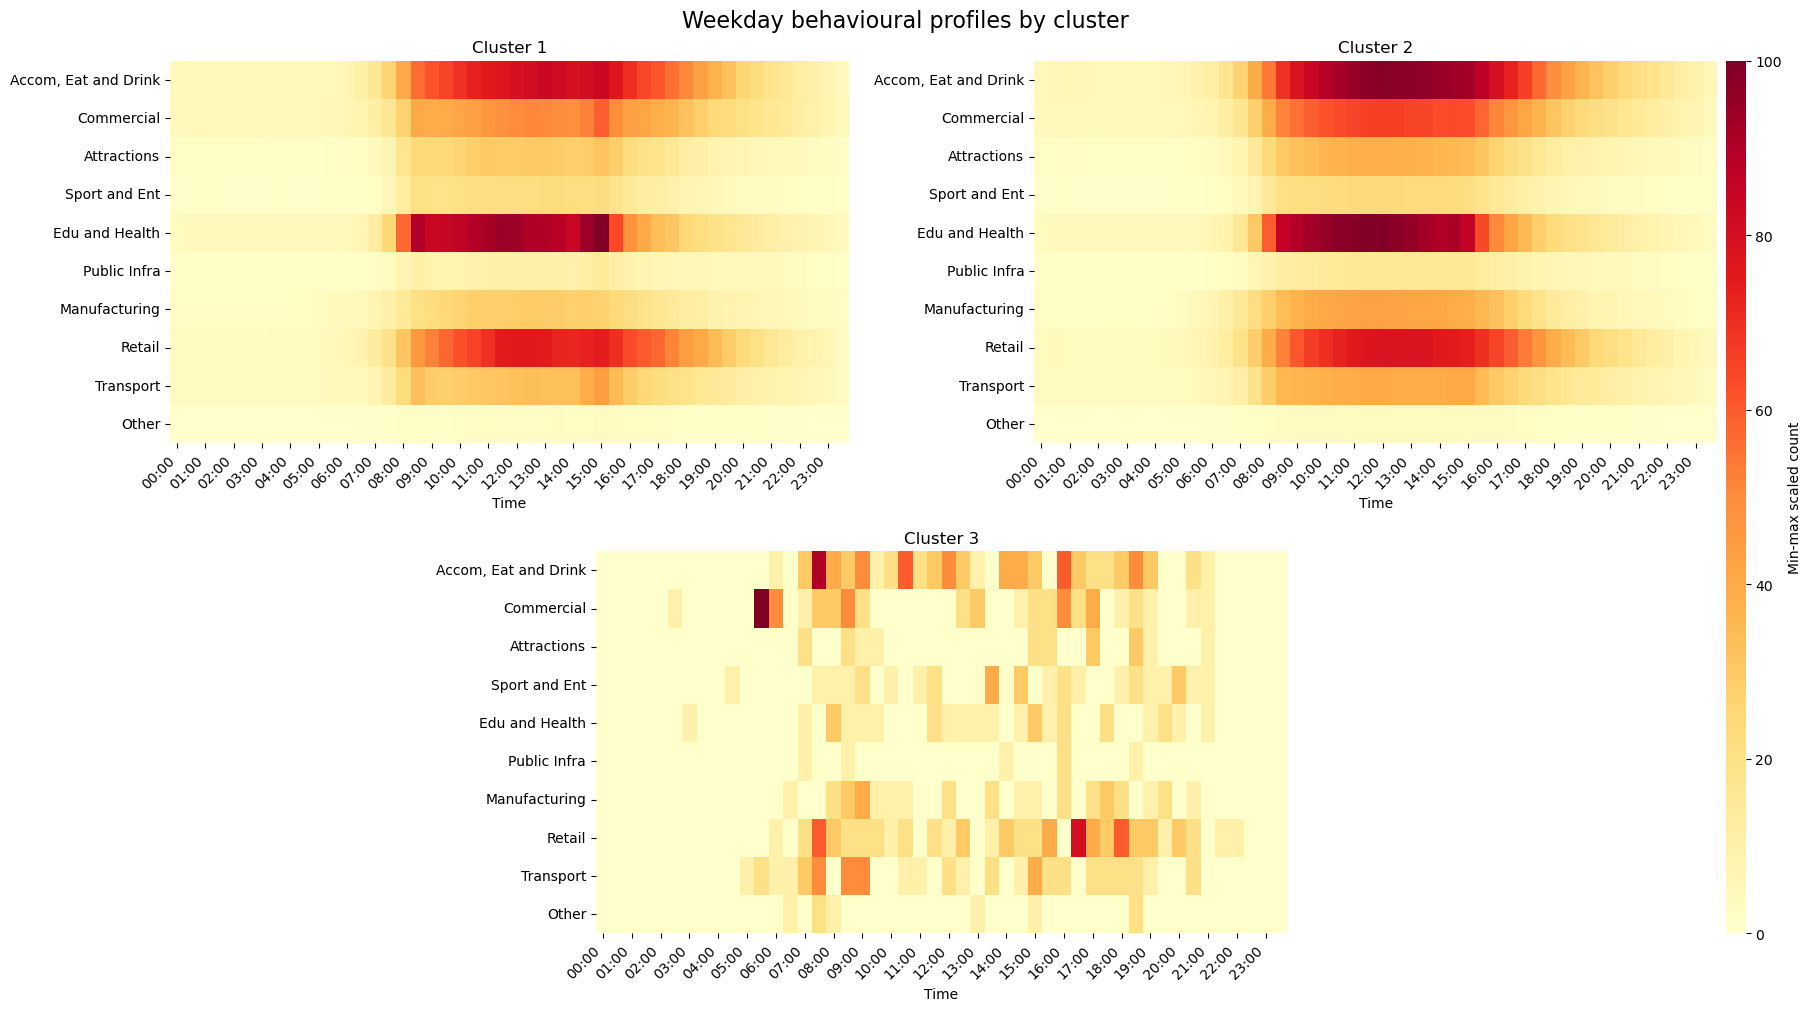

In [59]:
# Plot all non-noise weekday clusters in one figure and save it.
behavioural_profile_fig_dir = os.path.join(
    'pretrained_se_multimodaltrip',
    f'{city}_{str_study_period}',
    'figures',
    'weekday_behavioural_profiles',
)
os.makedirs(behavioural_profile_fig_dir, exist_ok=True)

fig, axes = plot_cluster_behavioral_profile_subplots(
    df_stays_weekday_to_plot,
    normalisation='minmax',
    include_home=False,
    include_outliers=False,
    ncols=2,
    cmap='YlOrRd'
)
fig_path = os.path.join(behavioural_profile_fig_dir, f'weekday_behavioural_profiles_all_clusters_minmax.png')
fig.savefig(fig_path, dpi=400, bbox_inches='tight')
print(f'Saved weekday behavioural profile heatmap figure to: {fig_path}')